# Projeto de rede neural

**Disciplina:** Matemática para Ciência de Dados  
**Curso:** Especialização em Deep Learning  
**Instituição:** CIn - Centro de Informática - UFPE  
**Professor**: Adenilton José da Silva  
**Aluno:** João Pedro da Silva Rodrigues

## 1. Objetivo

Este projeto visa implementação de uma rede neural manualmente. Desse modo, para validar a implementação manual de uma rede neural com retropropagação, a rede é treinada em um conjunto de dados real, e os seus resultados são comparados com os de uma rede equivalente construída em Keras.

## 2. Base de dados

A base binária real **Ionosphere**, da UCI, contém 351 sinais coletados por 16 antenas de radar em Goose Bay, Labrador. Seus 34 atributos contínuos descrevem os sinais: retornos `good` indicam estrutura na ionosfera e retornos `bad` atravessam a ionosfera. Os atributos foram reduzidos a duas componentes por PCA e convertidos em z-score.

## 3. Topologia

A rede possui duas entradas, duas camadas ocultas com quatro neurônios com uma função de ativação sigmoide em cada e uma saída também com sigmoide. Os quatro neurônios de cada camada oferecem flexibilidade na fronteira de decisão e mantêm a rede compacta.

As implementações manual e Keras usam os mesmos pesos e vieses iniciais, erro quadrático médio, taxa adaptativa, treinamento em lote completo e 2.000 épocas.

### Diagrama da topologia

Cada entrada é conectada à primeira camada oculta. Suas quatro ativações alimentam a segunda camada oculta, que é combinada pelo neurônio de saída antes do cálculo da perda.

![Topologia da rede neural](figuras/topologia_rede.svg)

![Equações do backpropagation](figuras/grafo_backpropagation_rede.svg)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.inspection import DecisionBoundaryDisplay

resultados = np.load('resultados_rede.npz')
print(f"Acurácia manual: {float(resultados['acuracia_manual']):.2%}")
print(f"Acurácia Keras:  {float(resultados['acuracia_keras']):.2%}")

Acurácia manual: 84.33%
Acurácia Keras:  84.33%


## 4. Metodologia

No passo *forward*, cada camada calcula a soma ponderada das entradas e aplica a função sigmoide. No passo *backward*, a regra da cadeia fornece os gradientes dos pesos e vieses, que são atualizados por gradiente descendente.

A função de perda utilizada é o erro quadrático médio,   
$$
\mathrm{MSE} = \frac{1}{N}\sum_{i=1}^{N}(\hat{y}_i-d_i)^2.   
$$
Ela foi escolhida por se corresponder à função `mean_squared_error` usada no Keras. Essa equivalência permite que os resultados da rede manual sejam comparados aos da implementaçao em Keras. 

Para essa aplicação uma taxa de aprendizado adaptativa foi escolhida, seguindo `10 / (1 + 0,001 × época)` nas duas implementações. O valor inicial compensa os gradientes pequenos produzidos pelas camadas sigmoides, e sua redução gradual torna os ajustes finais mais estáveis. Durante o treinamento, observou-se que a taxa adaptativa gerou uma convergência mais rápida comparada a uma taxa constante, justificando a escolha.

A curva de aprendizagem registra o erro quadrático médio por época. A região de decisão usa as probabilidades previstas pela rede manual e `DecisionBoundaryDisplay`, do scikit-learn.

## 5. Resultados

### Curva de aprendizagem

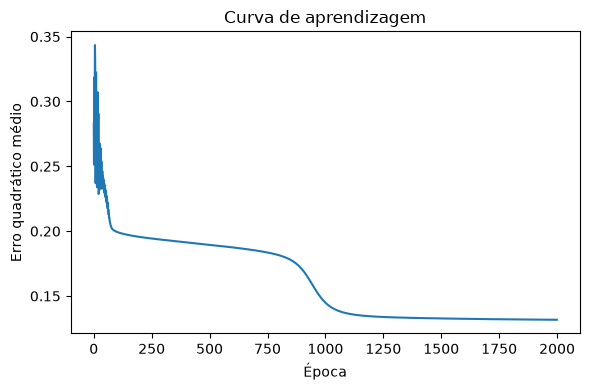

In [ ]:
figura, eixo = plt.subplots(figsize=(6, 4))
eixo.plot(resultados['historico'])
eixo.set_xlabel('Época')
eixo.set_ylabel('Erro quadrático médio')
eixo.set_title('Curva de aprendizagem')
figura.tight_layout()
figura.savefig('figuras/curva_aprendizagem.svg')
plt.show()

### Região de decisão

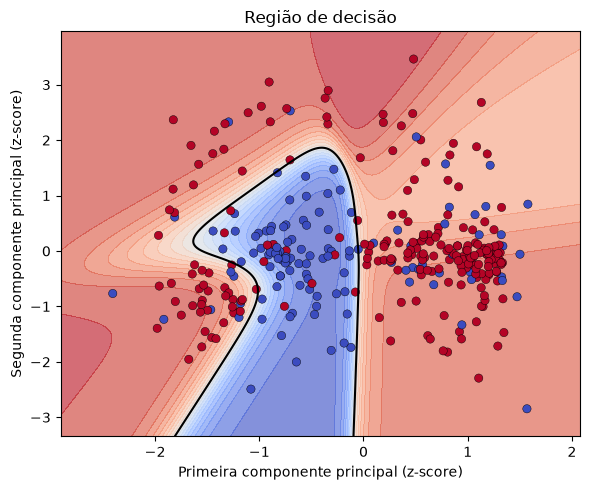

In [ ]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))


X, Y = resultados['X'], resultados['Y']
w0, b0 = resultados['w0'], resultados['b0']
w1, b1 = resultados['w1'], resultados['b1']
w2, b2 = resultados['w2'], resultados['b2']
margem = 0.5
eixo_x = np.linspace(X[:, 0].min() - margem, X[:, 0].max() + margem, 300)
eixo_y = np.linspace(X[:, 1].min() - margem, X[:, 1].max() + margem, 300)
grade_x, grade_y = np.meshgrid(eixo_x, eixo_y)
grade = np.c_[grade_x.ravel(), grade_y.ravel()]
camada_1 = sigmoid(grade @ w0.T + b0)
camada_2 = sigmoid(camada_1 @ w1.T + b1)
probabilidades = sigmoid(camada_2 @ w2 + b2)
probabilidades = probabilidades.reshape(grade_x.shape)

figura, eixo = plt.subplots(figsize=(6, 5))
display = DecisionBoundaryDisplay(
    xx0=grade_x, xx1=grade_y, response=probabilidades, n_classes=2,
    xlabel='Primeira componente principal (z-score)', ylabel='Segunda componente principal (z-score)'
)
display.plot(plot_method='contourf', ax=eixo, levels=np.linspace(0, 1, 21),
             cmap='coolwarm', alpha=0.65)
eixo.contour(grade_x, grade_y, probabilidades, levels=[0.5],
             colors='black', linewidths=1.5)
eixo.scatter(X[:, 0], X[:, 1], c=Y, cmap='coolwarm',
             edgecolors='black', linewidths=0.3)
eixo.set_title('Região de decisão')
figura.tight_layout()
figura.savefig('figuras/regiao_decisao.svg')
plt.show()

A perda diminui ao longo do treinamento, indicando aprendizagem. A rede manual e a rede Keras atingem **84,33% de acurácia**, mostrando que as duas implementações produzem o mesmo resultado sob as mesmas condições.

## 6. Conclusão

A implementação manual demonstra como realizar os cálculos de propagação e retropropagação do erro. A comparação com a implementação em Keras confirmou o resultado com uma interface de alto nível, servindo como evidência da corretude da implementação manual. 